# CSE543 Revised Final Project
## Comprehensive Robot Path-Planning Benchmark

**Title:** Comparative Evaluation of Grid-Based, Sampling-Based, and Incremental Path-Planning Algorithms in Static and Changing Environments

**Course:** CSE543 - Introduction to Robotics  
**Semester:** Summer 2026  
**Submitted to:** Dr. Shahnewaz Siddique, Associate Professor, North South University  
**Submitted by:** Md. Ahanaf Tahmid (2535421650) and Md. Mahmud Hasan (2535430650)

### What this notebook implements

- Static planners: Dijkstra, A*, Greedy Best-First Search, RRT, RRT*, and PRM
- Incremental planner: D* Lite, compared with fresh A* replanning
- Five map families, multiple obstacle densities, robot radii, map seeds, and planner seeds
- Collision-safe edges, diagonal corner-cut prevention, obstacle inflation, path validation, and controlled random seeds
- Metrics: success, runtime, path length, optimality ratio, expanded nodes, clearance, turns, and smoothness
- Automatic tables, heatmaps, boxplots, sensitivity graphs, path panels, and dynamic replanning graphs

> Start with `QUICK_MODE = True`. Change it to `False` only for the final large experiment.


In [ ]:


import math
import time
import heapq
import random
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import binary_dilation, distance_transform_edt
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

OUTPUT_DIR = Path("cse543_results")
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

MASTER_SEED = 543
random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)


## 1. Experimental configuration

Quick Mode is intended for debugging and presentation practice. Full Study Mode creates the larger dataset for the final report. Parameters are written in one place so the study is reproducible.


In [ ]:
QUICK_MODE = False

if QUICK_MODE:
    MAP_SIZE = 60
    MAP_TYPES = ["open", "random", "maze", "warehouse", "narrow"]
    DENSITIES = [0.10, 0.25]
    ROBOT_RADII = [1, 2]
    MAP_SEEDS = list(range(2))
    SAMPLER_SEEDS = list(range(2))
    RRT_ITERATIONS = 700
    RRT_STAR_ITERATIONS = 1000
    PRM_SAMPLES = 150
else:
    MAP_SIZE = 100
    MAP_TYPES = ["open", "random", "maze", "warehouse", "narrow"]
    DENSITIES = [0.10, 0.20, 0.30]
    ROBOT_RADII = [1, 2, 3]
    MAP_SEEDS = list(range(10))
    SAMPLER_SEEDS = list(range(5))
    RRT_ITERATIONS = 3000
    RRT_STAR_ITERATIONS = 5000
    PRM_SAMPLES = 450

START = (4, 4)
GOAL = (MAP_SIZE - 5, MAP_SIZE - 5)

ALGORITHM_ORDER = ["Dijkstra", "A*", "Greedy", "RRT", "RRT*", "PRM"]
STOCHASTIC_ALGORITHMS = {"RRT", "RRT*", "PRM"}

print("Mode:", "QUICK" if QUICK_MODE else "FULL STUDY")
print("Static conditions:", len(MAP_TYPES) * len(DENSITIES) * len(ROBOT_RADII) * len(MAP_SEEDS))


Mode: FULL STUDY
Static conditions: 450


## 2. Environment generation and robot footprint

The workspace is a binary occupancy grid. Obstacles are first generated on a raw map and then inflated with a circular structuring element. This converts a disk-shaped robot into a point while preserving collision safety.


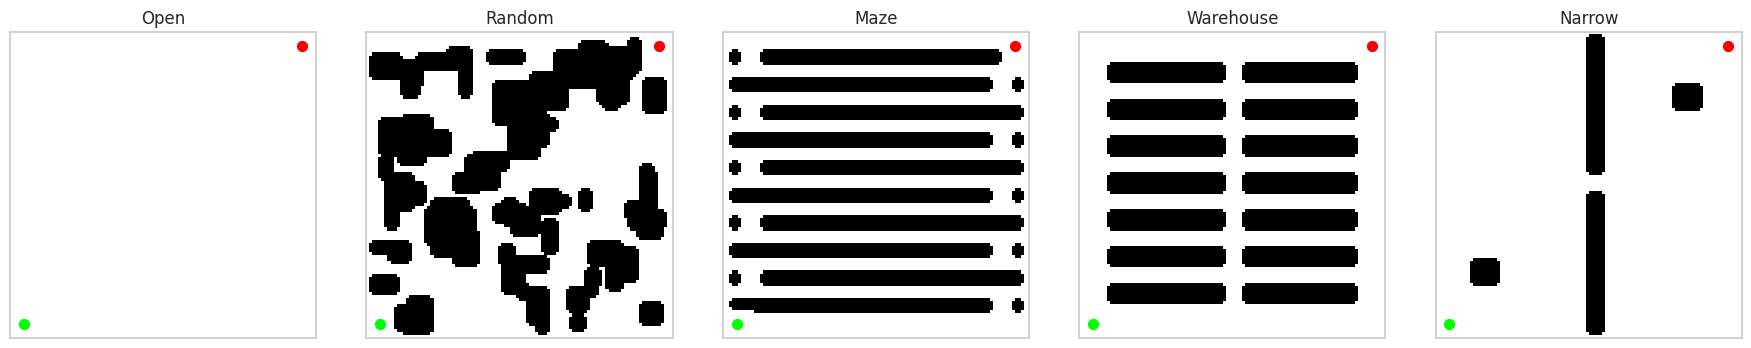

In [ ]:
def disk_structure(radius):
    y, x = np.ogrid[-radius:radius + 1, -radius:radius + 1]
    return (x * x + y * y <= radius * radius)


def protect_endpoint(raw, point, margin=3):
    x, y = point
    raw[max(0, x-margin):min(raw.shape[0], x+margin+1),
        max(0, y-margin):min(raw.shape[1], y+margin+1)] = 0


def inflate_obstacles(raw, radius):
    if radius <= 0:
        return raw.astype(np.uint8).copy()
    return binary_dilation(raw.astype(bool), structure=disk_structure(radius)).astype(np.uint8)


def generate_raw_environment(map_type, size, density, seed):
    rng = np.random.default_rng(seed)
    raw = np.zeros((size, size), dtype=np.uint8)

    if map_type == "open":
        pass

    elif map_type == "random":
        target = int(size * size * density)
        attempts = 0
        while int(raw.sum()) < target and attempts < 1000:
            h = int(rng.integers(3, max(4, size // 8)))
            w = int(rng.integers(3, max(4, size // 8)))
            x = int(rng.integers(2, max(3, size - h - 2)))
            y = int(rng.integers(2, max(3, size - w - 2)))
            raw[x:x+h, y:y+w] = 1
            attempts += 1

    elif map_type == "maze":
        spacing = max(8, int(13 - 12 * density))
        wall = 2 if density < 0.2 else 3
        flip = False
        for y in range(spacing, size - spacing, spacing):
            raw[3:size-3, y:y+wall] = 1
            gap = slice(5, 13) if flip else slice(size-13, size-5)
            raw[gap, y:y+wall] = 0
            flip = not flip

    elif map_type == "warehouse":
        shelf_w = 3 if density < 0.2 else 5
        for y in range(12, size - 8, 12):
            raw[10:size-10, y:y+shelf_w] = 1
            # Cross-aisles keep the warehouse navigable.
            raw[size//2-3:size//2+4, y:y+shelf_w] = 0

    elif map_type == "narrow":
        x = size // 2
        thickness = 2 if density < 0.2 else 4
        raw[x:x+thickness, 2:size-2] = 1
        gap_half = 5 if density < 0.2 else 3
        raw[x:x+thickness, size//2-gap_half:size//2+gap_half+1] = 0
        # Add blocks away from the main passage for the high-density condition.
        if density >= 0.2:
            raw[12:20, 18:25] = 1
            raw[size-22:size-14, size-25:size-18] = 1
    else:
        raise ValueError(f"Unknown map type: {map_type}")

    protect_endpoint(raw, START, margin=5)
    protect_endpoint(raw, GOAL, margin=5)
    return raw


def create_environment(map_type, density, robot_radius, seed):
    raw = generate_raw_environment(map_type, MAP_SIZE, density, seed)
    grid = inflate_obstacles(raw, robot_radius)
    protect_endpoint(grid, START, margin=1)
    protect_endpoint(grid, GOAL, margin=1)
    return grid


fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, map_type in zip(axes, MAP_TYPES):
    grid = create_environment(map_type, DENSITIES[-1], ROBOT_RADII[0], MASTER_SEED)
    ax.imshow(grid.T, origin="lower", cmap="binary")
    ax.scatter(*START, c="lime", s=50, label="Start")
    ax.scatter(*GOAL, c="red", s=50, label="Goal")
    ax.set_title(map_type.title())
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_environment_gallery.png", dpi=180, bbox_inches="tight")
plt.show()


## 3. Geometry, movement, and metrics

Diagonal movement is allowed only when it does not cut through an obstacle corner. Segment collision checking includes both endpoints. Every returned path is validated before it enters the results table.


In [ ]:
SQRT2 = math.sqrt(2.0)
GRID_MOVES = [
    (-1, 0, 1.0), (1, 0, 1.0), (0, -1, 1.0), (0, 1, 1.0),
    (-1, -1, SQRT2), (-1, 1, SQRT2), (1, -1, SQRT2), (1, 1, SQRT2)
]


def euclidean(a, b):
    return math.hypot(float(a[0]) - float(b[0]), float(a[1]) - float(b[1]))


def is_free(grid, p):
    x, y = int(round(p[0])), int(round(p[1]))
    return 0 <= x < grid.shape[0] and 0 <= y < grid.shape[1] and grid[x, y] == 0


def grid_neighbors(grid, p):
    x, y = p
    if not is_free(grid, p):
        return []
    result = []
    for dx, dy, cost in GRID_MOVES:
        q = (x + dx, y + dy)
        if not is_free(grid, q):
            continue
        if dx != 0 and dy != 0:
            if not is_free(grid, (x + dx, y)) or not is_free(grid, (x, y + dy)):
                continue
        result.append((q, cost))
    return result


def collision_free(grid, a, b):
    # Dense sampling prevents skipped occupied cells and includes both endpoints.
    samples = max(2, int(math.ceil(euclidean(a, b) * 3)) + 1)
    for t in np.linspace(0.0, 1.0, samples):
        p = (a[0] + (b[0] - a[0]) * t, a[1] + (b[1] - a[1]) * t)
        if not is_free(grid, p):
            return False
    return True


def path_length(path):
    if not path or len(path) < 2:
        return 0.0 if path else np.nan
    return float(sum(euclidean(a, b) for a, b in zip(path[:-1], path[1:])))


def turning_angles(path):
    if not path or len(path) < 3:
        return []
    values = []
    for a, b, c in zip(path[:-2], path[1:-1], path[2:]):
        v1 = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
        v2 = np.asarray(c, dtype=float) - np.asarray(b, dtype=float)
        denom = np.linalg.norm(v1) * np.linalg.norm(v2)
        if denom > 1e-12:
            cosine = float(np.clip(np.dot(v1, v2) / denom, -1.0, 1.0))
            values.append(abs(math.acos(cosine)))
    return values


def path_clearance(grid, path):
    if not path:
        return np.nan, np.nan
    clearance_map = distance_transform_edt(grid == 0)
    values = []
    for a, b in zip(path[:-1], path[1:]):
        samples = max(2, int(math.ceil(euclidean(a, b) * 2)) + 1)
        for t in np.linspace(0.0, 1.0, samples):
            x = int(round(a[0] + (b[0] - a[0]) * t))
            y = int(round(a[1] + (b[1] - a[1]) * t))
            values.append(float(clearance_map[x, y]))
    if len(path) == 1:
        x, y = map(int, path[0]); values.append(float(clearance_map[x, y]))
    return float(np.min(values)), float(np.mean(values))


def validate_path(grid, path, start=START, goal=GOAL, atol=1.5):
    if path is None or len(path) == 0:
        return False, "no path"
    if euclidean(path[0], start) > atol:
        return False, "wrong start"
    if euclidean(path[-1], goal) > atol:
        return False, "wrong goal"
    if any(not collision_free(grid, a, b) for a, b in zip(path[:-1], path[1:])):
        return False, "collision"
    return True, "valid"


@dataclass
class PlannerResult:
    path: object
    nodes: int
    extra: dict = field(default_factory=dict)


## 4. Grid-based planners

Dijkstra and A* use identical movement rules. With the admissible Euclidean heuristic, A* must return the same optimal path cost as Dijkstra. Greedy Best-First Search is included as a fast but non-optimal baseline.


In [ ]:
def reconstruct(parent, node):
    path = [node]
    while node in parent:
        node = parent[node]
        path.append(node)
    return path[::-1]


def best_first_search(grid, start, goal, mode="astar"):
    if not is_free(grid, start) or not is_free(grid, goal):
        return PlannerResult(None, 0)

    g_cost = {start: 0.0}
    parent = {}
    closed = set()
    counter = 0

    def priority(node, g):
        h = euclidean(node, goal)
        if mode == "dijkstra": return g
        if mode == "greedy": return h
        return g + h

    queue = [(priority(start, 0.0), counter, 0.0, start)]
    while queue:
        _, _, queued_g, current = heapq.heappop(queue)
        if current in closed:
            continue
        if mode != "greedy" and queued_g > g_cost.get(current, math.inf) + 1e-12:
            continue
        closed.add(current)
        if current == goal:
            return PlannerResult(reconstruct(parent, current), len(closed))

        for nxt, step_cost in grid_neighbors(grid, current):
            if nxt in closed:
                continue
            candidate = g_cost[current] + step_cost
            if mode == "greedy":
                if nxt not in g_cost:
                    g_cost[nxt] = candidate
                    parent[nxt] = current
                    counter += 1
                    heapq.heappush(queue, (priority(nxt, candidate), counter, candidate, nxt))
            elif candidate + 1e-12 < g_cost.get(nxt, math.inf):
                g_cost[nxt] = candidate
                parent[nxt] = current
                counter += 1
                heapq.heappush(queue, (priority(nxt, candidate), counter, candidate, nxt))
    return PlannerResult(None, len(closed))


def dijkstra(grid, start=START, goal=GOAL):
    return best_first_search(grid, start, goal, "dijkstra")


def astar(grid, start=START, goal=GOAL):
    return best_first_search(grid, start, goal, "astar")


def greedy_bfs(grid, start=START, goal=GOAL):
    return best_first_search(grid, start, goal, "greedy")


## 5. Sampling-based planners

The implementations below fix the important validity problems found in the earlier notebook:

- steering never overshoots the sampled point;
- every tree, roadmap, rewire, and goal edge is collision-checked;
- RRT* propagates cost changes to descendants;
- RRT* selects the lowest-cost valid goal connection;
- PRM is fully implemented rather than left as a placeholder.


In [ ]:
@dataclass(eq=False)
class TreeNode:
    p: tuple
    parent: object = None
    cost: float = 0.0
    children: set = field(default_factory=set)


def random_free_point(grid, rng):
    for _ in range(10000):
        p = (float(rng.integers(0, grid.shape[0])), float(rng.integers(0, grid.shape[1])))
        if is_free(grid, p):
            return p
    raise RuntimeError("Could not sample a free point")


def steer(a, b, step_size):
    d = euclidean(a, b)
    if d <= step_size:
        return (float(b[0]), float(b[1]))
    scale = step_size / d
    return (float(a[0] + (b[0] - a[0]) * scale),
            float(a[1] + (b[1] - a[1]) * scale))


def tree_path(node):
    path = []
    while node is not None:
        path.append(node.p)
        node = node.parent
    return path[::-1]


def reparent(node, new_parent, new_cost):
    if node.parent is not None:
        node.parent.children.discard(node)
    node.parent = new_parent
    new_parent.children.add(node)
    delta = new_cost - node.cost
    stack = [node]
    while stack:
        current = stack.pop()
        current.cost += delta
        stack.extend(current.children)


def rrt(grid, start=START, goal=GOAL, iterations=RRT_ITERATIONS,
        step_size=4.0, goal_bias=0.10, goal_threshold=5.0, seed=0):
    rng = np.random.default_rng(seed)
    root = TreeNode(tuple(map(float, start)))
    tree = [root]
    seen = {(round(root.p[0], 2), round(root.p[1], 2))}

    for _ in range(iterations):
        sample = tuple(map(float, goal)) if rng.random() < goal_bias else random_free_point(grid, rng)
        nearest = min(tree, key=lambda n: euclidean(n.p, sample))
        new_p = steer(nearest.p, sample, step_size)
        key = (round(new_p[0], 2), round(new_p[1], 2))
        if key in seen or not collision_free(grid, nearest.p, new_p):
            continue
        node = TreeNode(new_p, nearest, nearest.cost + euclidean(nearest.p, new_p))
        nearest.children.add(node)
        tree.append(node); seen.add(key)

        if euclidean(new_p, goal) <= goal_threshold and collision_free(grid, new_p, goal):
            return PlannerResult(tree_path(node) + [tuple(map(float, goal))], len(tree), {"tree": tree})
    return PlannerResult(None, len(tree), {"tree": tree})


def rrt_star(grid, start=START, goal=GOAL, iterations=RRT_STAR_ITERATIONS,
             step_size=4.0, goal_bias=0.10, neighbor_radius=10.0,
             goal_threshold=5.0, seed=0):
    rng = np.random.default_rng(seed)
    root = TreeNode(tuple(map(float, start)))
    tree = [root]
    seen = {(round(root.p[0], 2), round(root.p[1], 2))}
    convergence = []

    for iteration in range(iterations):
        sample = tuple(map(float, goal)) if rng.random() < goal_bias else random_free_point(grid, rng)
        nearest = min(tree, key=lambda n: euclidean(n.p, sample))
        new_p = steer(nearest.p, sample, step_size)
        key = (round(new_p[0], 2), round(new_p[1], 2))
        if key in seen or not collision_free(grid, nearest.p, new_p):
            continue

        # A bounded adaptive radius gives dense early rewiring without excessive late cost.
        adaptive = neighbor_radius * math.sqrt(max(math.log(len(tree) + 1), 1.0) / (len(tree) + 1))
        radius = max(step_size * 1.5, min(neighbor_radius, adaptive * 3.0))
        near_nodes = [n for n in tree if euclidean(n.p, new_p) <= radius]

        best_parent = nearest
        best_cost = nearest.cost + euclidean(nearest.p, new_p)
        for candidate in near_nodes:
            candidate_cost = candidate.cost + euclidean(candidate.p, new_p)
            if candidate_cost + 1e-12 < best_cost and collision_free(grid, candidate.p, new_p):
                best_parent, best_cost = candidate, candidate_cost

        node = TreeNode(new_p, best_parent, best_cost)
        best_parent.children.add(node)
        tree.append(node); seen.add(key)

        for candidate in near_nodes:
            if candidate is best_parent or candidate is root:
                continue
            rewired_cost = node.cost + euclidean(node.p, candidate.p)
            if rewired_cost + 1e-12 < candidate.cost and collision_free(grid, node.p, candidate.p):
                reparent(candidate, node, rewired_cost)

        if iteration % max(1, iterations // 50) == 0:
            goal_nodes = [n for n in tree if euclidean(n.p, goal) <= goal_threshold
                          and collision_free(grid, n.p, goal)]
            best = min((n.cost + euclidean(n.p, goal) for n in goal_nodes), default=np.nan)
            convergence.append((iteration, best))

    goal_nodes = [n for n in tree if euclidean(n.p, goal) <= goal_threshold
                  and collision_free(grid, n.p, goal)]
    if not goal_nodes:
        return PlannerResult(None, len(tree), {"tree": tree, "convergence": convergence})
    best = min(goal_nodes, key=lambda n: n.cost + euclidean(n.p, goal))
    return PlannerResult(tree_path(best) + [tuple(map(float, goal))], len(tree),
                         {"tree": tree, "convergence": convergence})


def prm(grid, start=START, goal=GOAL, n_samples=PRM_SAMPLES, k_neighbors=12, seed=0):
    rng = np.random.default_rng(seed)
    points = [tuple(map(float, start)), tuple(map(float, goal))]
    seen = {points[0], points[1]}
    while len(points) < n_samples + 2:
        p = random_free_point(grid, rng)
        if p not in seen:
            points.append(p); seen.add(p)

    tree = cKDTree(np.asarray(points))
    graph = defaultdict(list)
    for i, point in enumerate(points):
        _, indices = tree.query(point, k=min(k_neighbors + 1, len(points)))
        for j in np.atleast_1d(indices):
            j = int(j)
            if i == j:
                continue
            weight = euclidean(point, points[j])
            if collision_free(grid, point, points[j]):
                graph[i].append((j, weight))
                graph[j].append((i, weight))

    queue = [(0.0, 0)]
    costs = {0: 0.0}
    parent = {}
    closed = set()
    while queue:
        current_cost, current = heapq.heappop(queue)
        if current in closed:
            continue
        closed.add(current)
        if current == 1:
            ids = [1]
            while ids[-1] in parent:
                ids.append(parent[ids[-1]])
            path = [points[i] for i in ids[::-1]]
            return PlannerResult(path, len(closed), {"points": points, "graph": graph})
        for nxt, weight in graph[current]:
            candidate = current_cost + weight
            if candidate + 1e-12 < costs.get(nxt, math.inf):
                costs[nxt] = candidate
                parent[nxt] = current
                heapq.heappush(queue, (candidate, nxt))
    return PlannerResult(None, len(closed), {"points": points, "graph": graph})


## 6. Automated correctness tests

These tests check optimality agreement, collision safety, endpoint validity, and the existence of paths in an open environment. A failed assertion must be fixed before running the final benchmark.


In [ ]:
def run_correctness_tests():
    test_maps = [
        create_environment("open", 0.10, 1, 1),
        create_environment("maze", 0.10, 1, 2),
        create_environment("warehouse", 0.10, 1, 3),
    ]
    for grid in test_maps:
        d = dijkstra(grid)
        a = astar(grid)
        assert d.path is not None and a.path is not None
        assert abs(path_length(d.path) - path_length(a.path)) < 1e-8, "A* and Dijkstra disagree"
        assert validate_path(grid, d.path)[0]
        assert validate_path(grid, a.path)[0]

    open_grid = test_maps[0]
    sample_results = [
        rrt(open_grid, iterations=500, seed=10),
        rrt_star(open_grid, iterations=700, seed=10),
        prm(open_grid, n_samples=100, seed=10),
    ]
    for result in sample_results:
        assert result.path is not None, "A sampling planner failed the open-map test"
        assert validate_path(open_grid, result.path)[0], "A sampling planner returned an invalid path"
    print("All static planner correctness tests passed.")


run_correctness_tests()


All static planner correctness tests passed.


## 7. Common evaluation wrapper

Failed or invalid paths are recorded explicitly. Optimality ratio is computed against A* on the identical grid.


In [ ]:
def evaluate_planner(name, planner, grid, optimal_length, metadata):
    start_time = time.perf_counter()
    result = planner()
    elapsed_ms = (time.perf_counter() - start_time) * 1000.0
    valid, reason = validate_path(grid, result.path)
    success = int(valid)
    path = result.path if valid else None
    angles = turning_angles(path)
    min_clearance, mean_clearance = path_clearance(grid, path)
    length = path_length(path)
    record = dict(metadata)
    record.update({
        "Algorithm": name,
        "Success": success,
        "FailureReason": "" if valid else reason,
        "RuntimeMs": elapsed_ms,
        "PathLength": length,
        "OptimalityRatio": length / optimal_length if valid and optimal_length > 0 else np.nan,
        "NodesExplored": result.nodes,
        "MinClearance": min_clearance,
        "MeanClearance": mean_clearance,
        "TurnCount": len(angles),
        "TotalTurningRad": float(sum(angles)) if angles else (0.0 if valid else np.nan),
        "MeanTurnRad": float(np.mean(angles)) if angles else (0.0 if valid else np.nan),
    })
    return record, result


def planner_factory(name, grid, seed):
    if name == "Dijkstra": return lambda: dijkstra(grid)
    if name == "A*": return lambda: astar(grid)
    if name == "Greedy": return lambda: greedy_bfs(grid)
    if name == "RRT": return lambda: rrt(grid, iterations=RRT_ITERATIONS, seed=seed)
    if name == "RRT*": return lambda: rrt_star(grid, iterations=RRT_STAR_ITERATIONS, seed=seed)
    if name == "PRM": return lambda: prm(grid, n_samples=PRM_SAMPLES, seed=seed)
    raise ValueError(name)


## 8. Static benchmark

Each deterministic planner runs once on a condition. Each stochastic planner runs with every configured planner seed. Unsolvable generated instances are marked and skipped rather than silently included.


In [ ]:
def run_static_benchmark():
    records = []
    total = len(MAP_TYPES) * len(DENSITIES) * len(ROBOT_RADII) * len(MAP_SEEDS)
    completed = 0

    for map_type in MAP_TYPES:
        for density in DENSITIES:
            for radius in ROBOT_RADII:
                for map_seed in MAP_SEEDS:
                    grid = create_environment(map_type, density, radius, MASTER_SEED + map_seed)
                    optimal = astar(grid)
                    completed += 1
                    if optimal.path is None:
                        print(f"Skipped unsolvable map: {map_type}, density={density}, radius={radius}, seed={map_seed}")
                        continue
                    optimal_length = path_length(optimal.path)
                    base = {
                        "MapType": map_type,
                        "Density": density,
                        "RobotRadius": radius,
                        "MapSeed": map_seed,
                    }
                    for name in ALGORITHM_ORDER:
                        seeds = SAMPLER_SEEDS if name in STOCHASTIC_ALGORITHMS else [0]
                        for planner_seed in seeds:
                            metadata = dict(base, PlannerSeed=planner_seed)
                            record, _ = evaluate_planner(
                                name, planner_factory(name, grid, MASTER_SEED + planner_seed),
                                grid, optimal_length, metadata
                            )
                            records.append(record)
                    print(f"Completed condition {completed}/{total}", end="\r")

    frame = pd.DataFrame(records)
    frame.to_csv(OUTPUT_DIR / "static_benchmark_results.csv", index=False)
    print(f"\nSaved {len(frame)} static runs.")
    return frame


results = run_static_benchmark()
results.head(10)


Skipped unsolvable map: random, density=0.2, radius=3, seed=0
Skipped unsolvable map: random, density=0.3, radius=2, seed=7
Skipped unsolvable map: random, density=0.3, radius=3, seed=0
Skipped unsolvable map: random, density=0.3, radius=3, seed=2
Skipped unsolvable map: random, density=0.3, radius=3, seed=4
Skipped unsolvable map: random, density=0.3, radius=3, seed=5
Skipped unsolvable map: random, density=0.3, radius=3, seed=6
Skipped unsolvable map: random, density=0.3, radius=3, seed=7
Skipped unsolvable map: random, density=0.3, radius=3, seed=8
Skipped unsolvable map: random, density=0.3, radius=3, seed=9
Skipped unsolvable map: maze, density=0.3, radius=3, seed=0
Skipped unsolvable map: maze, density=0.3, radius=3, seed=1
Skipped unsolvable map: maze, density=0.3, radius=3, seed=2
Skipped unsolvable map: maze, density=0.3, radius=3, seed=3
Skipped unsolvable map: maze, density=0.3, radius=3, seed=4
Skipped unsolvable map: maze, density=0.3, radius=3, seed=5
Skipped unsolvable m

,MapType,Density,RobotRadius,MapSeed,PlannerSeed,Algorithm,Success,FailureReason,RuntimeMs,PathLength,OptimalityRatio,NodesExplored,MinClearance,MeanClearance,TurnCount,TotalTurningRad,MeanTurnRad
0,open,0.1,1,0,0,Dijkstra,1,,347.097713,128.693434,1.000000,9932,6.403124,70.716618,90,0.000002,2.107342e-08
1,open,0.1,1,0,0,A*,1,,3.522028,128.693434,1.000000,92,6.403124,70.716618,90,0.000002,2.107342e-08
2,open,0.1,1,0,0,Greedy,1,,3.391095,128.693434,1.000000,92,6.403124,70.716618,90,0.000002,2.107342e-08
3,open,0.1,1,0,0,RRT,1,,30.400614,151.059173,1.173791,117,6.403124,69.621258,37,23.016270,6.220614e-01
4,open,0.1,1,0,1,RRT,1,,26.914205,165.459179,1.285685,131,6.403124,72.490516,41,23.009120,5.611981e-01
5,open,0.1,1,0,2,RRT,1,,24.709307,156.396564,1.215265,111,6.403124,69.890507,38,18.054442,4.751169e-01
6,open,0.1,1,0,3,RRT,1,,24.003515,148.081944,1.150657,104,6.403124,70.437862,36,18.743816,5.206616e-01
7,open,0.1,1,0,4,RRT,1,,31.254822,151.538972,1.177519,110,6.403124,71.047543,37,17.890888,4.835375e-01
8,open,0.1,1,0,0,RRT*,1,,15675.960807,129.163473,1.003652,3707,6.403124,70.915894,28,2.324439,8.301569e-02
9,open,0.1,1,0,1,RRT*,1,,8991.695136,129.314025,1.004822,3765,6.403124,70.987301,28,2.357293,8.418905e-02


## 9. Result tables

The tables below are also saved as CSV files for use in the report and presentation.


In [ ]:
overall_table = results.groupby("Algorithm", observed=True).agg(
    Runs=("Success", "size"),
    SuccessRate=("Success", "mean"),
    RuntimeMeanMs=("RuntimeMs", "mean"),
    RuntimeMedianMs=("RuntimeMs", "median"),
    PathLengthMean=("PathLength", "mean"),
    OptimalityMean=("OptimalityRatio", "mean"),
    NodesMean=("NodesExplored", "mean"),
    MinClearanceMean=("MinClearance", "mean"),
    MeanTurnRad=("MeanTurnRad", "mean"),
).reindex(ALGORITHM_ORDER).round(4)

environment_table = results.pivot_table(
    index="Algorithm", columns="MapType", values="Success", aggfunc="mean"
).reindex(ALGORITHM_ORDER).round(3)

density_table = results.pivot_table(
    index="Algorithm", columns="Density", values=["Success", "RuntimeMs", "PathLength"], aggfunc="mean"
).reindex(ALGORITHM_ORDER).round(3)

radius_table = results.pivot_table(
    index="Algorithm", columns="RobotRadius", values=["Success", "MinClearance"], aggfunc="mean"
).reindex(ALGORITHM_ORDER).round(3)

overall_table.to_csv(OUTPUT_DIR / "table_overall.csv")
environment_table.to_csv(OUTPUT_DIR / "table_by_environment.csv")
density_table.to_csv(OUTPUT_DIR / "table_by_density.csv")
radius_table.to_csv(OUTPUT_DIR / "table_by_robot_radius.csv")

display(overall_table)
display(environment_table)
display(density_table)
display(radius_table)


,Runs,SuccessRate,RuntimeMeanMs,RuntimeMedianMs,PathLengthMean,OptimalityMean,NodesMean,MinClearanceMean,MeanTurnRad
Algorithm,,,,,,,,,
Dijkstra,430,1.0000,135.9162,138.0641,180.8811,1.0000,7201.7884,2.2022,0.0499
A*,430,1.0000,48.3469,48.1577,180.8811,1.0000,2418.7628,2.2022,0.0937
Greedy,430,1.0000,4.9430,2.8013,188.7214,1.0420,257.1907,2.2022,0.0758
RRT,2150,0.8098,177.4887,64.3069,172.6178,1.1799,363.4070,2.3835,0.5434
RRT*,2150,0.8744,5972.8863,6650.4747,146.0344,0.9825,2943.5349,2.2949,0.1377
PRM,2150,0.8237,611.1280,581.1479,161.7599,1.0718,386.0609,2.4613,0.2918


MapType,maze,narrow,open,random,warehouse
Algorithm,,,,,
Dijkstra,1.00,1.000,1.0,1.000,1.0
A*,1.00,1.000,1.0,1.000,1.0
Greedy,1.00,1.000,1.0,1.000,1.0
RRT,0.15,0.911,1.0,0.928,1.0
RRT*,0.40,0.956,1.0,0.975,1.0
PRM,0.50,0.689,1.0,0.902,1.0


PathLength                   RuntimeMs                     Success  \
Density          0.1      0.2      0.3       0.1       0.2       0.3     0.1   
Algorithm                                                                      
Dijkstra     190.094  195.240  154.000   146.479   126.022   135.075   1.000   
A*           190.094  195.240  154.000    47.705    49.275    48.026   1.000   
Greedy       196.500  202.900  163.688     6.142     4.640     3.914   1.000   
RRT          166.930  175.428  175.918   141.753   192.547   201.280   0.809   
RRT*         140.909  147.733  149.608  6331.737  5723.906  5845.180   0.851   
PRM          161.020  156.922  168.149   618.873   610.624   602.833   0.892   

                         
Density      0.2    0.3  
Algorithm                
Dijkstra   1.000  1.000  
A*         1.000  1.000  
Greedy     1.000  1.000  
RRT        0.793  0.829  
RRT*       0.836  0.945  
PRM        0.783  0.792

MinClearance               Success              
RobotRadius            1      2      3       1      2      3
Algorithm                                                   
Dijkstra           2.203  2.171  2.237   1.000  1.000  1.000
A*                 2.203  2.171  2.237   1.000  1.000  1.000
Greedy             2.203  2.171  2.237   1.000  1.000  1.000
RRT                2.197  2.435  2.568   0.877  0.783  0.763
RRT*               2.151  2.296  2.487   0.947  0.860  0.808
PRM                2.261  2.359  2.917   0.940  0.828  0.685

## 10. Main comparison graphs

This section produces grouped bars, line plots, boxplots, heatmaps, and trade-off scatter plots. All figures are saved automatically.


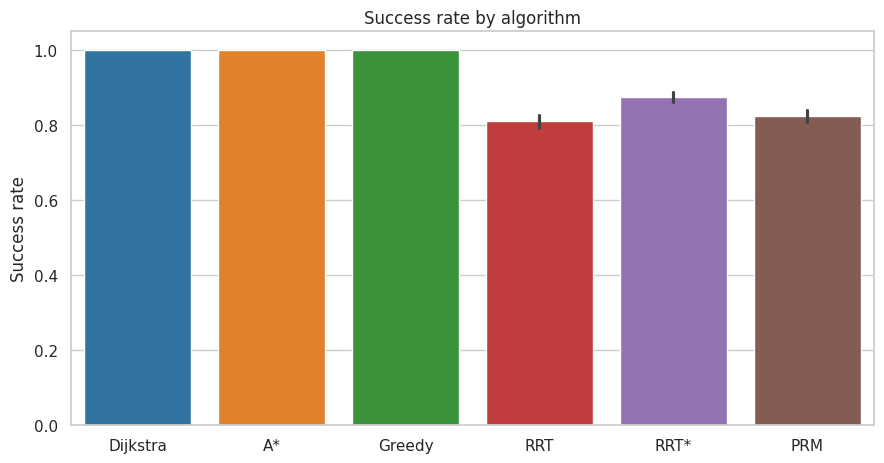

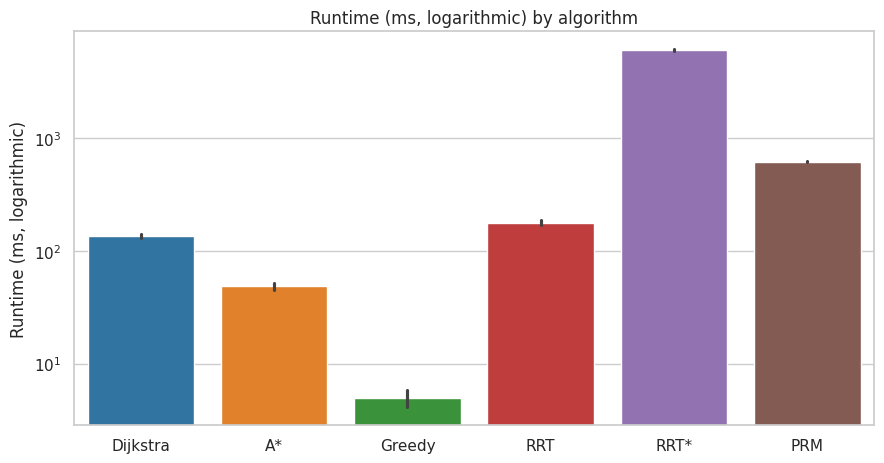

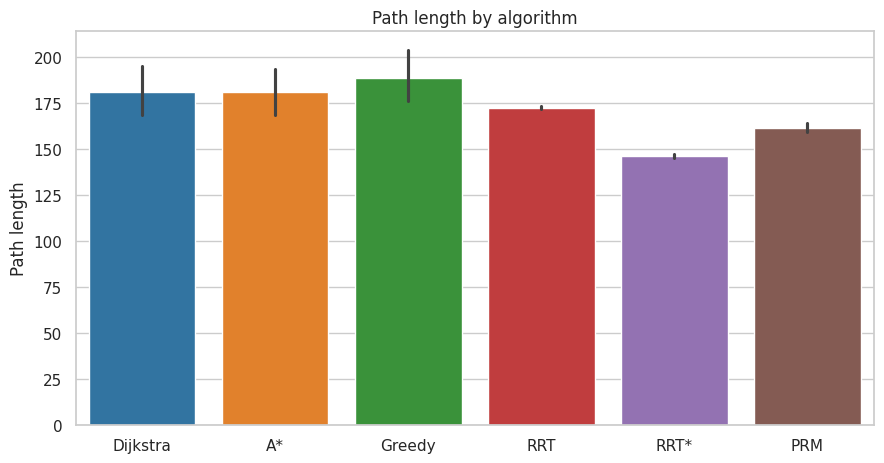

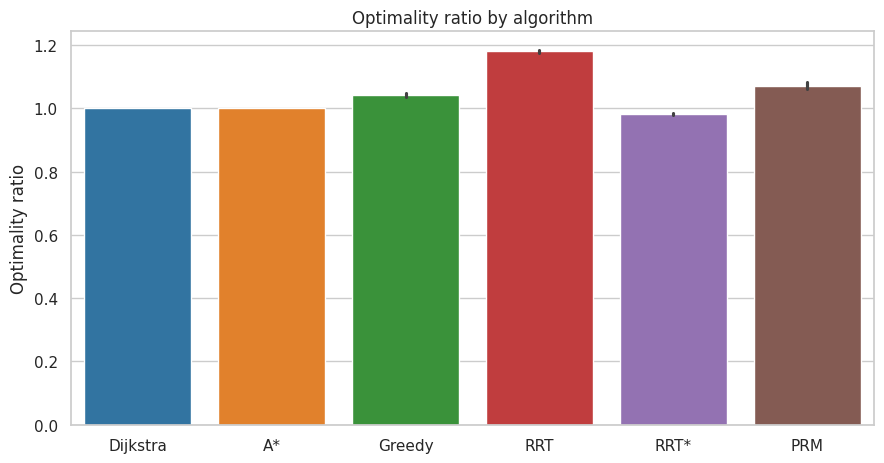

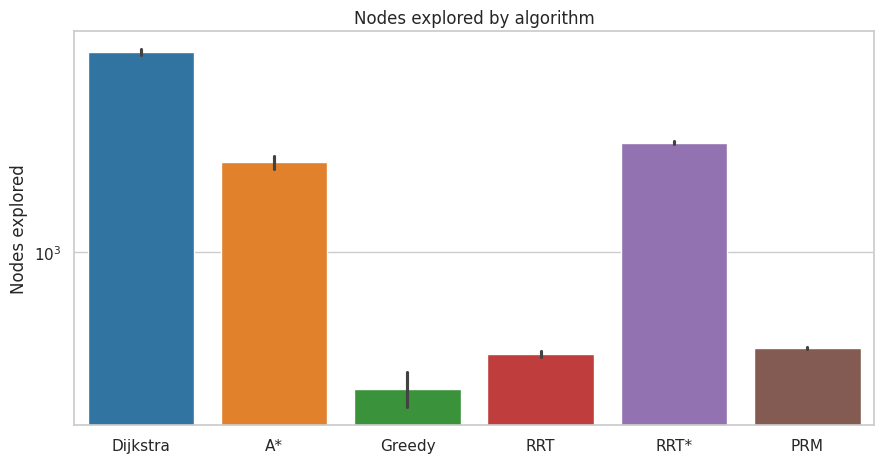

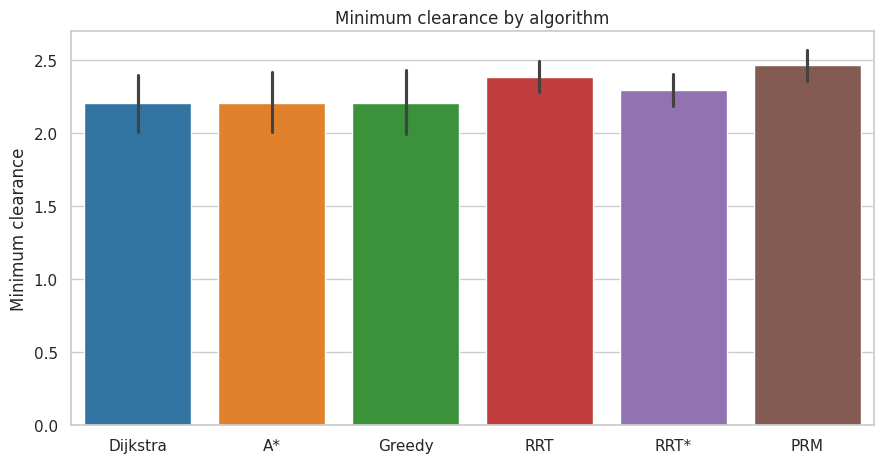

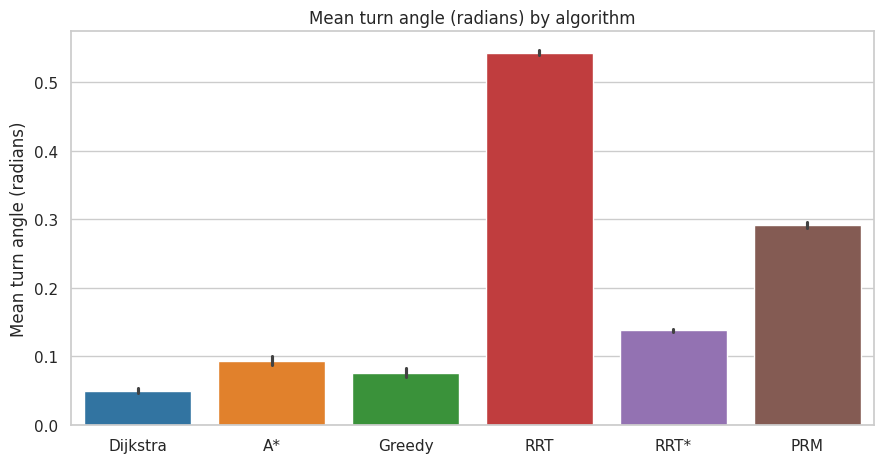

In [ ]:
def finish_figure(filename):
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()


successful = results[results["Success"] == 1].copy()
palette = dict(zip(ALGORITHM_ORDER, sns.color_palette("tab10", len(ALGORITHM_ORDER))))

# Graphs 2-8: overall metric comparisons
metric_specs = [
    ("Success", "Success rate", "02_overall_success.png"),
    ("RuntimeMs", "Runtime (ms, logarithmic)", "03_overall_runtime.png"),
    ("PathLength", "Path length", "04_overall_path_length.png"),
    ("OptimalityRatio", "Optimality ratio", "05_overall_optimality.png"),
    ("NodesExplored", "Nodes explored", "06_overall_nodes.png"),
    ("MinClearance", "Minimum clearance", "07_overall_clearance.png"),
    ("MeanTurnRad", "Mean turn angle (radians)", "08_overall_smoothness.png"),
]

for metric, ylabel, filename in metric_specs:
    data = results if metric in {"Success", "RuntimeMs", "NodesExplored"} else successful
    plt.figure(figsize=(9, 4.8))
    sns.barplot(data=data, x="Algorithm", y=metric, order=ALGORITHM_ORDER,
                hue="Algorithm", palette=palette, legend=False, errorbar=("ci", 95))
    if metric in {"RuntimeMs", "NodesExplored"}:
        plt.yscale("log")
    plt.ylabel(ylabel); plt.xlabel("")
    plt.title(ylabel + " by algorithm")
    finish_figure(filename)


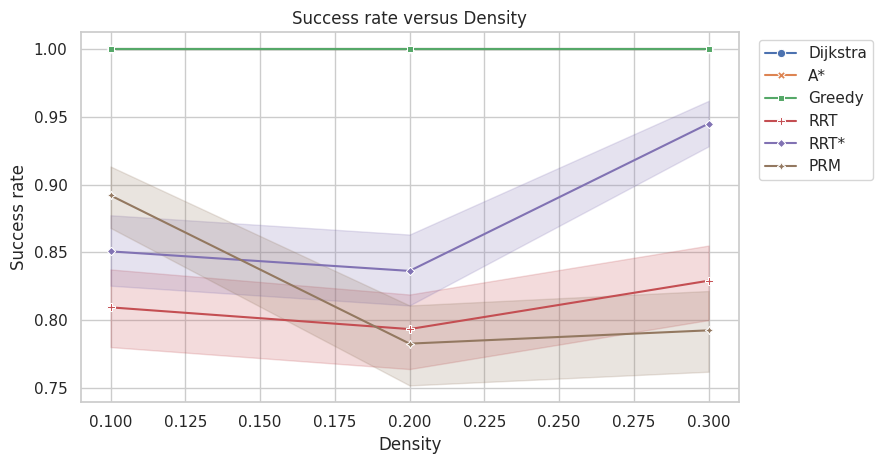

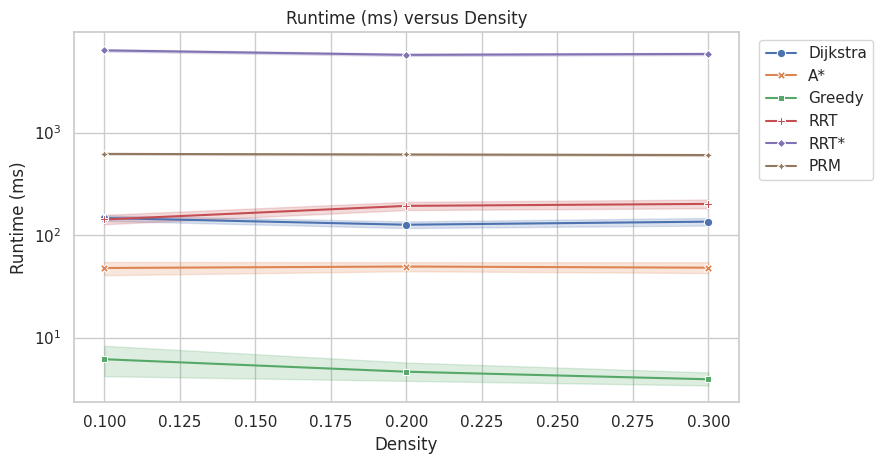

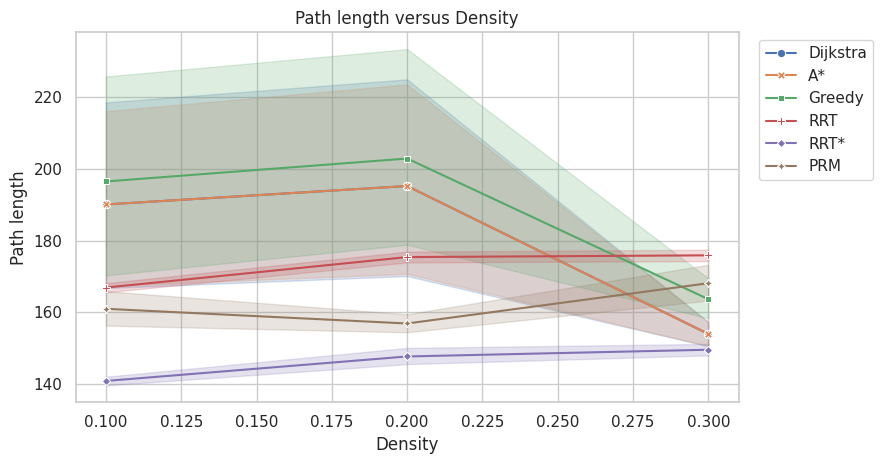

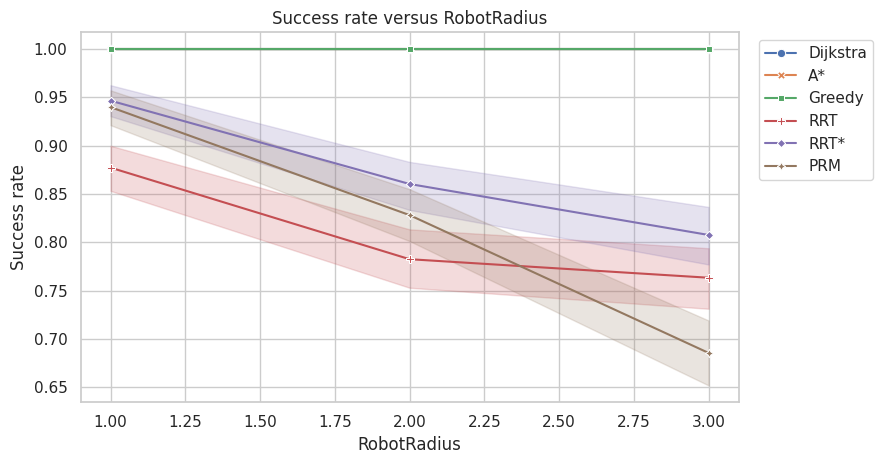

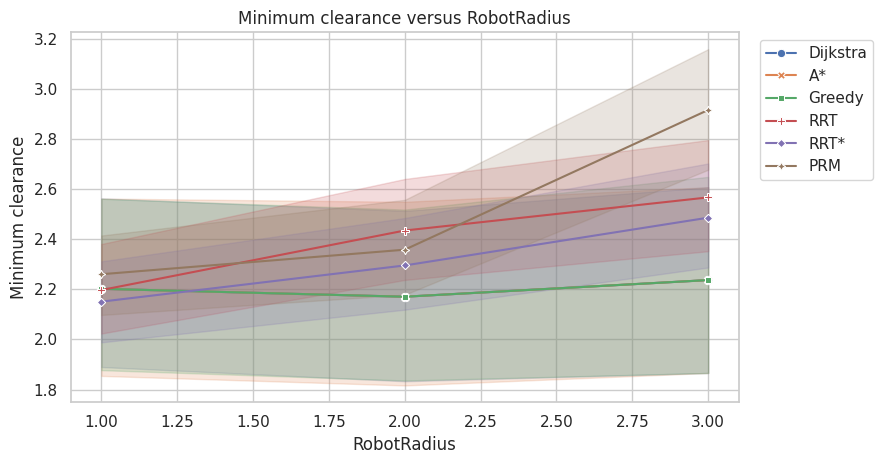

In [ ]:
# Graphs 9-13: condition effects
condition_specs = [
    ("Density", "Success", "Success rate", "09_density_success.png"),
    ("Density", "RuntimeMs", "Runtime (ms)", "10_density_runtime.png"),
    ("Density", "PathLength", "Path length", "11_density_path_length.png"),
    ("RobotRadius", "Success", "Success rate", "12_radius_success.png"),
    ("RobotRadius", "MinClearance", "Minimum clearance", "13_radius_clearance.png"),
]
for x, y, ylabel, filename in condition_specs:
    data = results if y in {"Success", "RuntimeMs"} else successful
    plt.figure(figsize=(9, 4.8))
    sns.lineplot(data=data, x=x, y=y, hue="Algorithm", hue_order=ALGORITHM_ORDER,
                 style="Algorithm", markers=True, dashes=False, errorbar=("ci", 95))
    if y == "RuntimeMs": plt.yscale("log")
    plt.ylabel(ylabel); plt.title(f"{ylabel} versus {x}")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    finish_figure(filename)


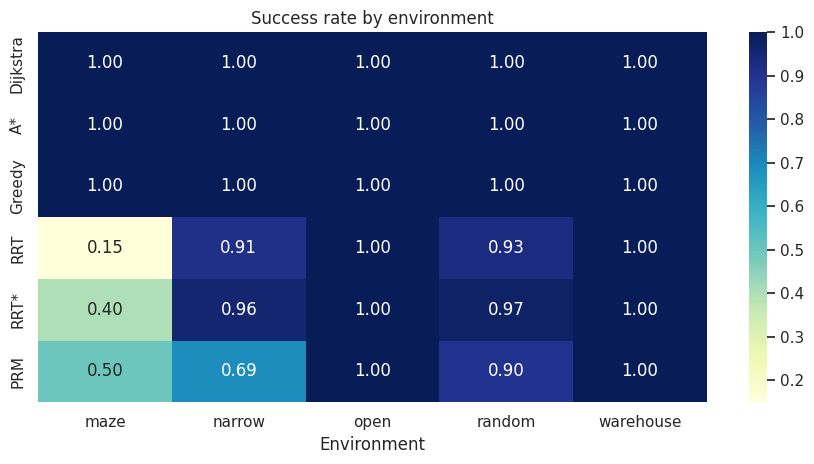

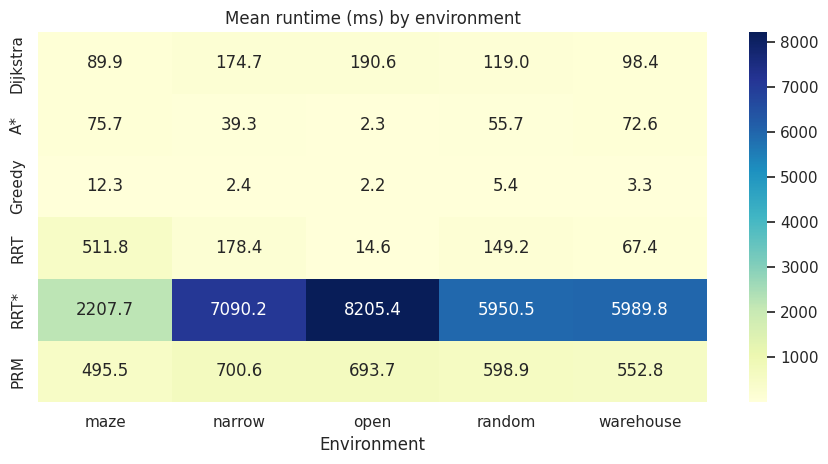

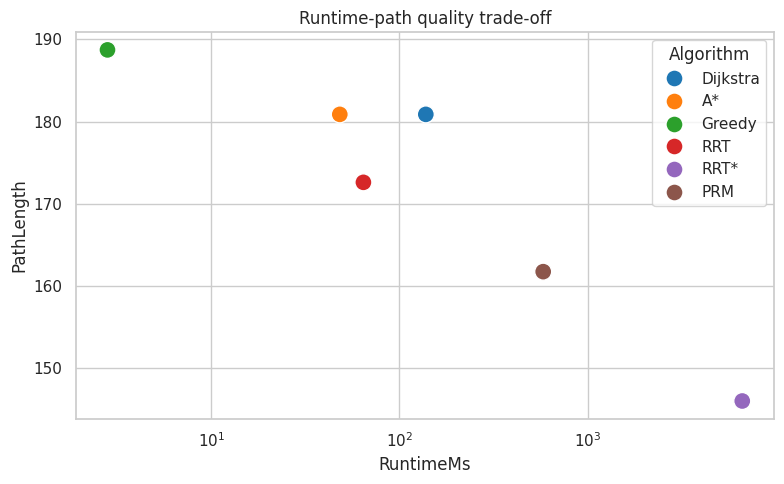

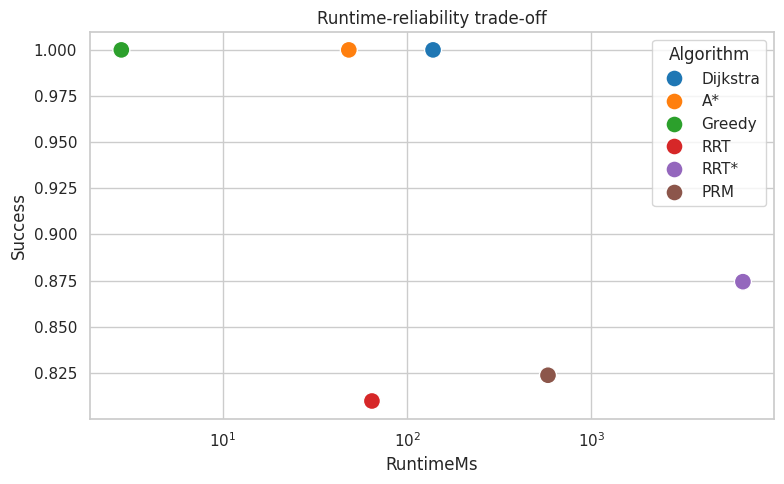

In [ ]:
# Graphs 14-15: heatmaps
for metric, filename, title, fmt in [
    ("Success", "14_success_heatmap.png", "Success rate by environment", ".2f"),
    ("RuntimeMs", "15_runtime_heatmap.png", "Mean runtime (ms) by environment", ".1f"),
]:
    table = results.pivot_table(index="Algorithm", columns="MapType", values=metric, aggfunc="mean")
    table = table.reindex(ALGORITHM_ORDER)
    plt.figure(figsize=(9, 4.8))
    sns.heatmap(table, annot=True, fmt=fmt, cmap="YlGnBu")
    plt.title(title); plt.xlabel("Environment"); plt.ylabel("")
    finish_figure(filename)

# Graphs 16-17: trade-off scatter plots
aggregate = results.groupby("Algorithm", observed=True).agg(
    Success=("Success", "mean"), RuntimeMs=("RuntimeMs", "median"),
    PathLength=("PathLength", "mean"), MinClearance=("MinClearance", "mean")
).reset_index()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=aggregate, x="RuntimeMs", y="PathLength", hue="Algorithm",
                hue_order=ALGORITHM_ORDER, s=150, palette=palette)
plt.xscale("log"); plt.title("Runtime-path quality trade-off")
finish_figure("16_runtime_path_tradeoff.png")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=aggregate, x="RuntimeMs", y="Success", hue="Algorithm",
                hue_order=ALGORITHM_ORDER, s=150, palette=palette)
plt.xscale("log"); plt.title("Runtime-reliability trade-off")
finish_figure("17_runtime_success_tradeoff.png")


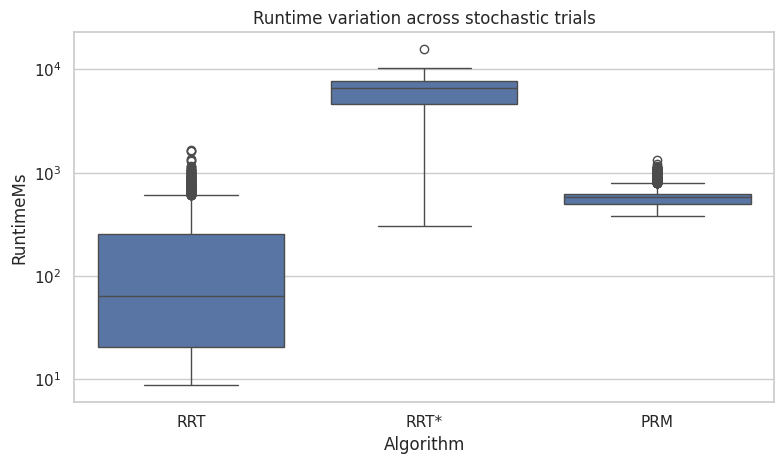

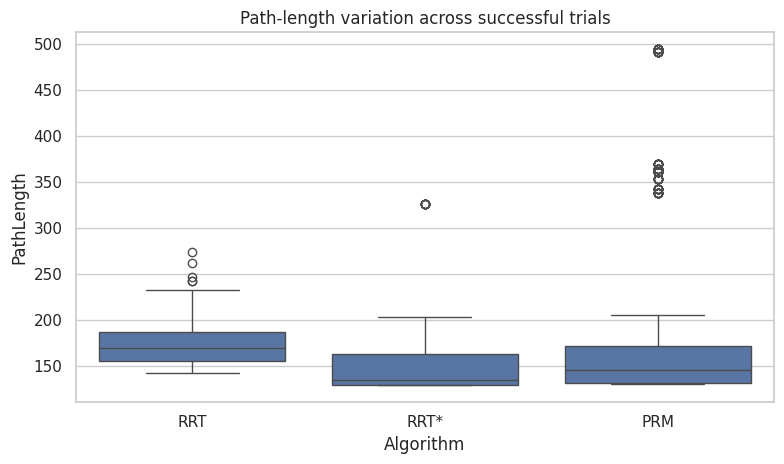

In [ ]:
# Graphs 18-19: stochastic variation across seeds
stochastic = results[results["Algorithm"].isin(STOCHASTIC_ALGORITHMS)]
for metric, filename, title in [
    ("RuntimeMs", "18_stochastic_runtime_boxplot.png", "Runtime variation across stochastic trials"),
    ("PathLength", "19_stochastic_length_boxplot.png", "Path-length variation across successful trials"),
]:
    data = stochastic if metric == "RuntimeMs" else stochastic[stochastic["Success"] == 1]
    plt.figure(figsize=(8, 4.8))
    sns.boxplot(data=data, x="Algorithm", y=metric, order=["RRT", "RRT*", "PRM"])
    if metric == "RuntimeMs": plt.yscale("log")
    plt.title(title)
    finish_figure(filename)


## 11. Six-planner path and search visualization

This figure is especially useful for the presentation because it shows all planners on the identical map.


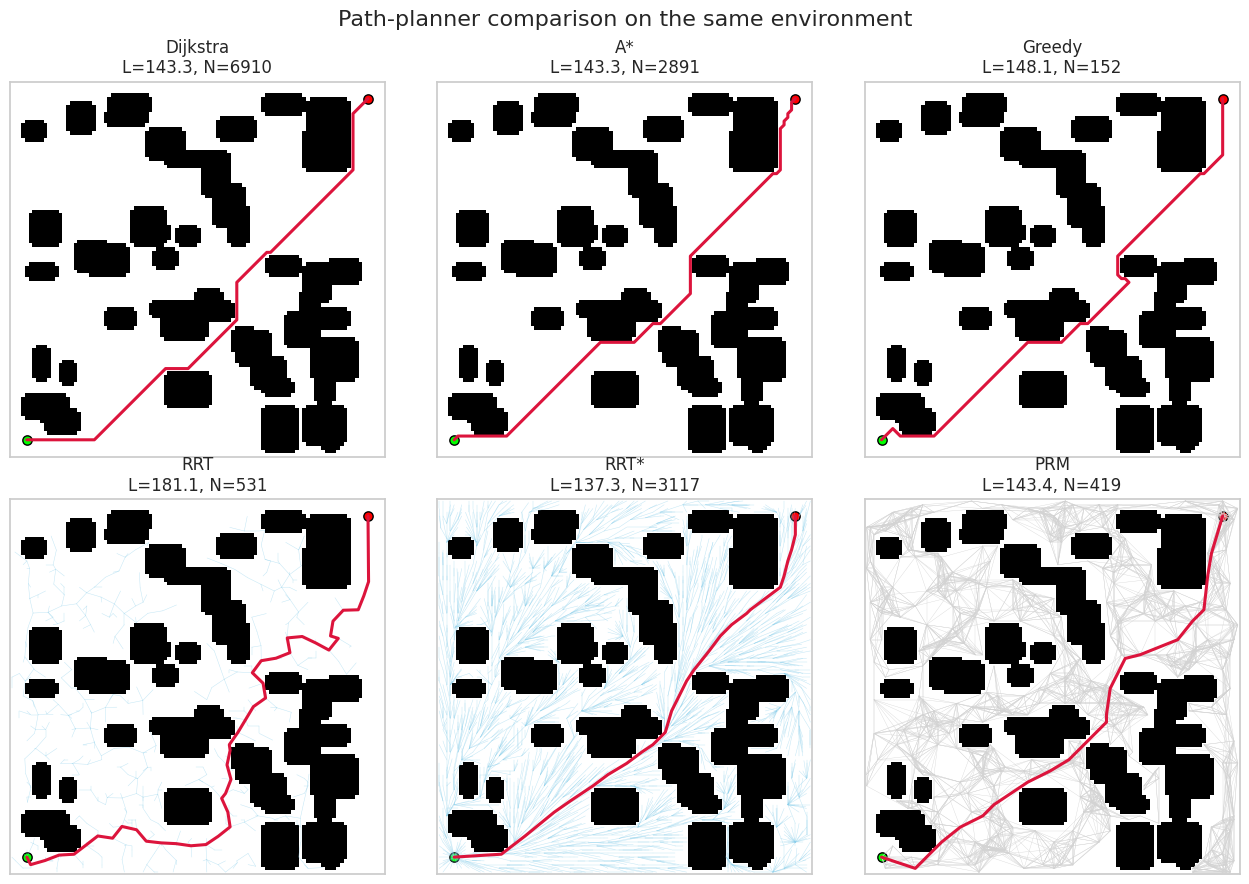

In [ ]:
def draw_path_result(ax, grid, name, result):
    ax.imshow(grid.T, origin="lower", cmap="binary")
    if name in {"RRT", "RRT*"}:
        for node in result.extra.get("tree", []):
            if node.parent is not None:
                ax.plot([node.p[0], node.parent.p[0]], [node.p[1], node.parent.p[1]],
                        color="skyblue", linewidth=0.35, alpha=0.5)
    if name == "PRM":
        points = result.extra.get("points", [])
        graph = result.extra.get("graph", {})
        for i, edges in graph.items():
            for j, _ in edges:
                if i < j:
                    a, b = points[i], points[j]
                    ax.plot([a[0], b[0]], [a[1], b[1]], color="lightgray", linewidth=0.25)
    if result.path:
        p = np.asarray(result.path)
        ax.plot(p[:, 0], p[:, 1], color="crimson", linewidth=2.2)
        subtitle = f"L={path_length(result.path):.1f}, N={result.nodes}"
    else:
        subtitle = "No path"
    ax.scatter(*START, c="lime", edgecolors="black", s=45)
    ax.scatter(*GOAL, c="red", edgecolors="black", s=45)
    ax.set_title(f"{name}\n{subtitle}")
    ax.set_xticks([]); ax.set_yticks([])


demo_grid = create_environment("random", 0.20, 1, MASTER_SEED + 20)
demo_results = {
    name: planner_factory(name, demo_grid, MASTER_SEED + 7)()
    for name in ALGORITHM_ORDER
}
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, name in zip(axes.ravel(), ALGORITHM_ORDER):
    draw_path_result(ax, demo_grid, name, demo_results[name])
plt.suptitle("Path-planner comparison on the same environment", fontsize=16)
finish_figure("20_six_planner_path_panel.png")


## 12. Parameter sensitivity and RRT* convergence

Parameter sweeps explain *why* a planner performs differently. They should be run on a fixed validation map and kept separate from the final test maps.


In [ ]:
validation_grid = create_environment("random", 0.18, 1, MASTER_SEED + 99)
validation_optimal = path_length(astar(validation_grid).path)

def sensitivity_runs():
    rows = []
    iterations_list = [300, 600, 1200] if QUICK_MODE else [500, 1000, 3000, 5000]
    sample_list = [80, 140, 220] if QUICK_MODE else [100, 250, 450, 700]
    seeds = range(3 if QUICK_MODE else 10)

    for value in iterations_list:
        for seed in seeds:
            t = time.perf_counter(); result = rrt(validation_grid, iterations=value, seed=seed)
            elapsed = (time.perf_counter() - t) * 1000
            valid = validate_path(validation_grid, result.path)[0]
            rows.append({"Planner": "RRT", "Parameter": "Iterations", "Value": value,
                         "Seed": seed, "Success": int(valid), "RuntimeMs": elapsed,
                         "PathLength": path_length(result.path) if valid else np.nan})

    for value in sample_list:
        for seed in seeds:
            t = time.perf_counter(); result = prm(validation_grid, n_samples=value, seed=seed)
            elapsed = (time.perf_counter() - t) * 1000
            valid = validate_path(validation_grid, result.path)[0]
            rows.append({"Planner": "PRM", "Parameter": "Samples", "Value": value,
                         "Seed": seed, "Success": int(valid), "RuntimeMs": elapsed,
                         "PathLength": path_length(result.path) if valid else np.nan})
    return pd.DataFrame(rows)


sensitivity = sensitivity_runs()
sensitivity.to_csv(OUTPUT_DIR / "parameter_sensitivity.csv", index=False)
display(sensitivity.groupby(["Planner", "Value"]).agg(
    Success=("Success", "mean"), RuntimeMs=("RuntimeMs", "mean"),
    PathLength=("PathLength", "mean")).round(3))


Success  RuntimeMs  PathLength
Planner Value                                
PRM     100        0.9    190.733     155.590
        250        1.0    399.440     145.962
        450        1.0    641.052     140.890
        700        1.0    842.849     139.214
RRT     500        0.9     38.941     177.565
        1000       0.9     52.159     177.565
        3000       1.0     82.052     182.022
        5000       1.0     54.697     182.022

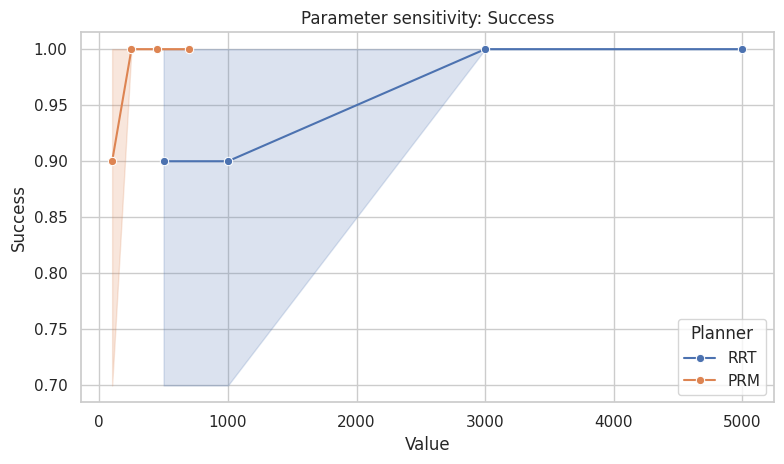

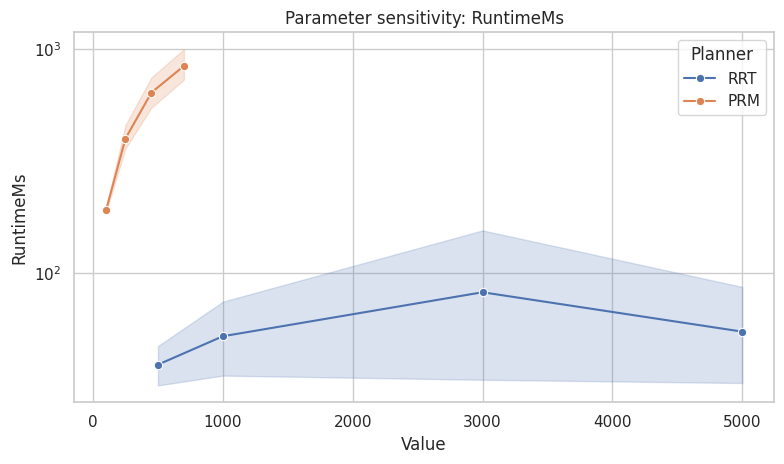

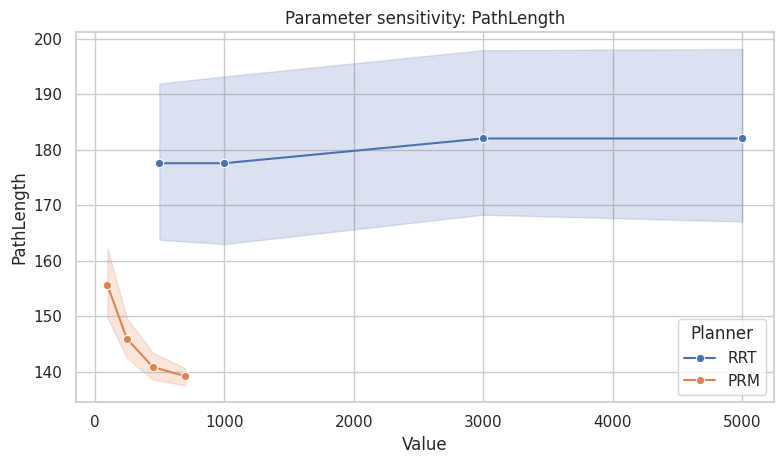

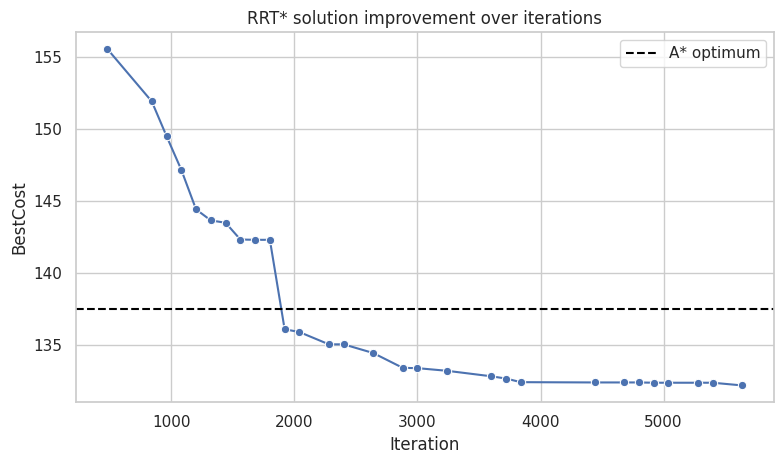

In [ ]:
# Graphs 21-23: sensitivity
for metric, filename in [
    ("Success", "21_parameter_success.png"),
    ("RuntimeMs", "22_parameter_runtime.png"),
    ("PathLength", "23_parameter_path_length.png"),
]:
    plt.figure(figsize=(8, 4.8))
    sns.lineplot(data=sensitivity, x="Value", y=metric, hue="Planner", marker="o", errorbar=("ci", 95))
    if metric == "RuntimeMs": plt.yscale("log")
    plt.title(f"Parameter sensitivity: {metric}")
    finish_figure(filename)

# Graph 24: RRT* convergence
convergence_result = rrt_star(
    validation_grid,
    iterations=1500 if QUICK_MODE else 6000,
    seed=MASTER_SEED + 100
)
conv = pd.DataFrame(convergence_result.extra["convergence"], columns=["Iteration", "BestCost"])
conv["BestCost"] = conv["BestCost"].ffill()
plt.figure(figsize=(8, 4.8))
sns.lineplot(data=conv, x="Iteration", y="BestCost", marker="o")
plt.axhline(validation_optimal, color="black", linestyle="--", label="A* optimum")
plt.legend(); plt.title("RRT* solution improvement over iterations")
finish_figure("24_rrt_star_convergence.png")


## 13. D* Lite for changing environments

D* Lite reuses previous search information when obstacle cells change. The experiment compares it with calculating a completely fresh A* path after every identical map update.


In [ ]:
class DStarLite:
    def __init__(self, grid, start, goal):
        self.grid = grid.copy()
        self.start = start
        self.goal = goal
        self.last = start
        self.km = 0.0
        self.g = np.full(grid.shape, np.inf, dtype=float)
        self.rhs = np.full(grid.shape, np.inf, dtype=float)
        self.rhs[goal] = 0.0
        self.heap = []
        self.active = {}
        self.counter = 0
        self.expanded_last = 0
        self._push(goal, self.calculate_key(goal))

    def heuristic(self, a, b):
        dx, dy = abs(a[0]-b[0]), abs(a[1]-b[1])
        return max(dx, dy) + (SQRT2 - 1.0) * min(dx, dy)

    def calculate_key(self, u):
        best = min(self.g[u], self.rhs[u])
        return (best + self.heuristic(self.start, u) + self.km, best)

    @staticmethod
    def key_less(a, b, eps=1e-9):
        # Lexicographic comparison with tolerance avoids false termination from
        # tiny floating-point differences in theoretically equal first keys.
        return a[0] < b[0] - eps or (abs(a[0] - b[0]) <= eps and a[1] < b[1] - eps)

    def _push(self, u, key):
        self.counter += 1
        self.active[u] = key
        heapq.heappush(self.heap, (key[0], key[1], self.counter, u))

    def _top_key(self):
        while self.heap:
            k1, k2, _, u = self.heap[0]
            if self.active.get(u) == (k1, k2):
                return (k1, k2)
            heapq.heappop(self.heap)
        return (math.inf, math.inf)

    def _pop(self):
        while self.heap:
            k1, k2, _, u = heapq.heappop(self.heap)
            if self.active.get(u) == (k1, k2):
                self.active.pop(u, None)
                return (k1, k2), u
        return (math.inf, math.inf), None

    def update_vertex(self, u):
        if u != self.goal:
            values = [cost + self.g[v] for v, cost in grid_neighbors(self.grid, u)]
            self.rhs[u] = min(values, default=math.inf)
        self.active.pop(u, None)
        if not math.isclose(self.g[u], self.rhs[u], rel_tol=1e-12, abs_tol=1e-12):
            self._push(u, self.calculate_key(u))

    def potential_predecessors(self, u):
        # Return adjacent free cells even when u has just become blocked.
        # Those cells may still have rhs values that depended on u's old g-value.
        values = []
        for dx, dy, _ in GRID_MOVES:
            q = (u[0] + dx, u[1] + dy)
            if 0 <= q[0] < self.grid.shape[0] and 0 <= q[1] < self.grid.shape[1] and is_free(self.grid, q):
                values.append(q)
        return values

    def compute_shortest_path(self, max_expansions=None):
        limit = max_expansions or self.grid.size * 50
        expanded = 0
        while (self.key_less(self._top_key(), self.calculate_key(self.start)) or
               not math.isclose(self.rhs[self.start], self.g[self.start], rel_tol=1e-12, abs_tol=1e-12)):
            if expanded >= limit:
                raise RuntimeError("D* Lite expansion limit reached")
            old_key, u = self._pop()
            if u is None:
                break
            new_key = self.calculate_key(u)
            if self.key_less(old_key, new_key):
                self._push(u, new_key)
            elif self.g[u] > self.rhs[u]:
                self.g[u] = self.rhs[u]
                for pred in self.potential_predecessors(u):
                    self.update_vertex(pred)
            else:
                self.g[u] = math.inf
                self.update_vertex(u)
                for pred in self.potential_predecessors(u):
                    self.update_vertex(pred)
            expanded += 1
        self.expanded_last = expanded

    def update_cells(self, changes):
        affected = set()
        for cell, occupied in changes:
            x, y = cell
            self.grid[x, y] = 1 if occupied else 0
            affected.add(cell)
            for dx, dy, _ in GRID_MOVES:
                q = (x + dx, y + dy)
                if 0 <= q[0] < self.grid.shape[0] and 0 <= q[1] < self.grid.shape[1]:
                    affected.add(q)
        for u in affected:
            self.update_vertex(u)

    def move_start(self, new_start):
        self.km += self.heuristic(self.last, new_start)
        self.last = new_start
        self.start = new_start

    def plan(self):
        self.compute_shortest_path()
        if not np.isfinite(self.g[self.start]):
            return PlannerResult(None, self.expanded_last)
        path = [self.start]
        current = self.start
        visited = {current}
        for _ in range(self.grid.size):
            if current == self.goal:
                return PlannerResult(path, self.expanded_last)
            choices = [(cost + self.g[nxt], nxt) for nxt, cost in grid_neighbors(self.grid, current)
                       if nxt not in visited or nxt == self.goal]
            if not choices:
                return PlannerResult(None, self.expanded_last)
            _, nxt = min(choices, key=lambda item: (item[0], self.heuristic(item[1], self.goal)))
            if not np.isfinite(self.g[nxt]):
                return PlannerResult(None, self.expanded_last)
            path.append(nxt); visited.add(nxt); current = nxt
        return PlannerResult(None, self.expanded_last)


In [ ]:
def build_change_sequence(base_grid, event_count=6):
    working = base_grid.copy()
    events = []
    for _ in range(event_count):
        current = astar(working).path
        if current is None or len(current) < 8:
            break
        candidate_ids = list(range(len(current)//3, 2*len(current)//3))
        selected = None
        for idx in candidate_ids:
            cell = current[idx]
            if cell in {START, GOAL} or working[cell] == 1:
                continue
            trial = working.copy(); trial[cell] = 1
            if astar(trial).path is not None:
                selected = cell
                break
        if selected is None:
            break
        working[selected] = 1
        events.append((selected, True))
    return events


def run_dynamic_benchmark():
    base = create_environment("random", 0.10, 1, MASTER_SEED + 333)
    events = build_change_sequence(base, 5 if QUICK_MODE else 12)
    rows = []

    # Fresh A* after every map change.
    grid_a = base.copy()
    for event_id, change in enumerate(events, 1):
        grid_a[change[0]] = 1
        t = time.perf_counter(); result = astar(grid_a); elapsed = (time.perf_counter()-t)*1000
        valid = validate_path(grid_a, result.path)[0]
        rows.append({"Method": "Repeated A*", "Event": event_id, "RuntimeMs": elapsed,
                     "NodesExplored": result.nodes, "Success": int(valid),
                     "PathLength": path_length(result.path) if valid else np.nan})

    # Incremental update of the same changes.
    dstar = DStarLite(base, START, GOAL)
    initial = dstar.plan()
    assert validate_path(base, initial.path)[0]
    for event_id, change in enumerate(events, 1):
        dstar.update_cells([change])
        t = time.perf_counter(); result = dstar.plan(); elapsed = (time.perf_counter()-t)*1000
        valid = validate_path(dstar.grid, result.path)[0]
        # Correctness oracle: D* Lite must agree with fresh A* path cost.
        oracle = astar(dstar.grid)
        if valid and oracle.path is not None:
            assert abs(path_length(result.path)-path_length(oracle.path)) < 1e-8
        rows.append({"Method": "D* Lite", "Event": event_id, "RuntimeMs": elapsed,
                     "NodesExplored": result.nodes, "Success": int(valid),
                     "PathLength": path_length(result.path) if valid else np.nan})

    frame = pd.DataFrame(rows)
    frame.to_csv(OUTPUT_DIR / "dynamic_replanning_results.csv", index=False)
    return base, events, frame


dynamic_grid, dynamic_events, dynamic_results = run_dynamic_benchmark()
dynamic_summary = dynamic_results.groupby("Method").agg(
    SuccessRate=("Success", "mean"), MeanRuntimeMs=("RuntimeMs", "mean"),
    MedianRuntimeMs=("RuntimeMs", "median"), MeanNodes=("NodesExplored", "mean"),
    MeanPathLength=("PathLength", "mean")
).round(4)
dynamic_summary.to_csv(OUTPUT_DIR / "table_dynamic_summary.csv")
display(dynamic_summary)


,SuccessRate,MeanRuntimeMs,MedianRuntimeMs,MeanNodes,MeanPathLength
Method,,,,,
D* Lite,1.0,77.8030,77.0181,420.7500,142.601
Repeated A*,1.0,79.0951,81.3219,4067.8333,142.601


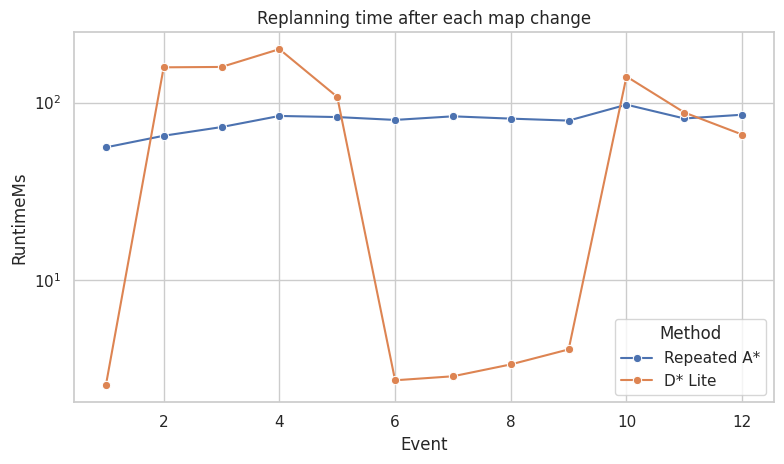

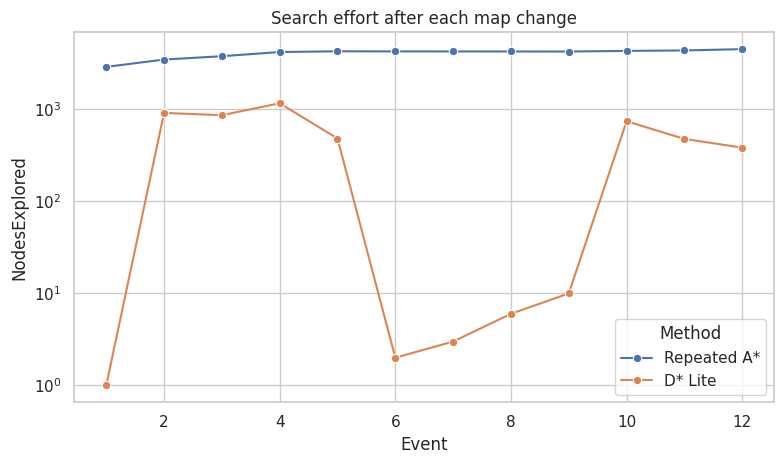

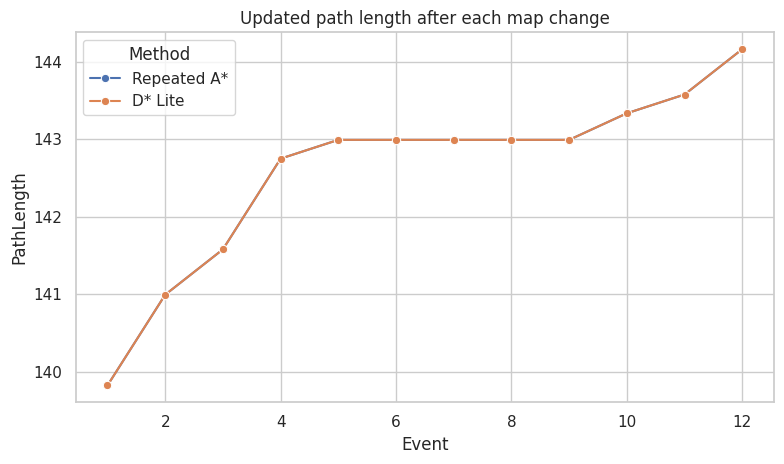

In [ ]:
# Graphs 25-27: dynamic replanning
for metric, filename, title in [
    ("RuntimeMs", "25_dynamic_replanning_time.png", "Replanning time after each map change"),
    ("NodesExplored", "26_dynamic_nodes.png", "Search effort after each map change"),
    ("PathLength", "27_dynamic_path_length.png", "Updated path length after each map change"),
]:
    plt.figure(figsize=(8, 4.8))
    sns.lineplot(data=dynamic_results, x="Event", y=metric, hue="Method", marker="o")
    if metric in {"RuntimeMs", "NodesExplored"}: plt.yscale("log")
    plt.title(title)
    finish_figure(filename)


## 14. Automatic ranking and final interpretation

The score below is a transparent summary, not a replacement for individual metrics. Reliability receives the highest weight. Runtime, path quality, search effort, and clearance receive smaller weights.


,SuccessRate,Runtime,Optimality,Nodes,Clearance,ReliabilityScore,RuntimeScore,QualityScore,SearchScore,ClearanceScore,OverallScore
Algorithm,,,,,,,,,,,
Greedy,1.0000,2.8013,1.0420,257.1907,2.2022,1.0000,1.0000,0.6991,1.0000,0.0000,0.8398
A*,1.0000,48.1577,1.0000,2418.7628,2.2022,1.0000,0.9932,0.9116,0.6887,0.0000,0.8343
Dijkstra,1.0000,138.0641,1.0000,7201.7884,2.2022,1.0000,0.9797,0.9116,0.0000,0.0000,0.7282
PRM,0.8237,581.1479,1.0718,386.0609,2.4613,0.0733,0.9130,0.5481,0.9814,1.0000,0.5651
RRT*,0.8744,6650.4747,0.9825,2943.5349,2.2949,0.3399,0.0000,1.0000,0.6132,0.3578,0.4467
RRT,0.8098,64.3069,1.1799,363.4070,2.3835,0.0000,0.9907,0.0000,0.9847,0.6998,0.4158


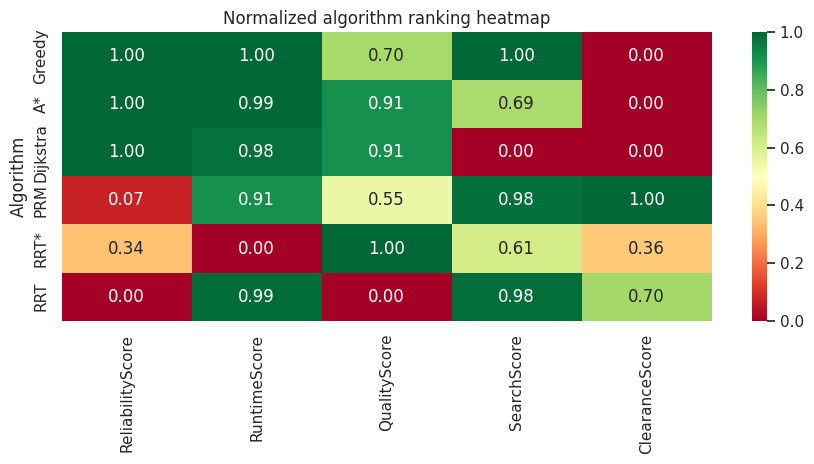

In [ ]:
ranking = results.groupby("Algorithm", observed=True).agg(
    SuccessRate=("Success", "mean"),
    Runtime=("RuntimeMs", "median"),
    Optimality=("OptimalityRatio", "mean"),
    Nodes=("NodesExplored", "mean"),
    Clearance=("MinClearance", "mean"),
).reindex(ALGORITHM_ORDER)

def minmax(series, higher_is_better=False):
    series = series.astype(float).fillna(series.max())
    span = series.max() - series.min()
    if span < 1e-12:
        return pd.Series(1.0, index=series.index)
    normalized = (series - series.min()) / span
    return normalized if higher_is_better else 1.0 - normalized

ranking["ReliabilityScore"] = minmax(ranking["SuccessRate"], True)
ranking["RuntimeScore"] = minmax(ranking["Runtime"])
ranking["QualityScore"] = minmax(ranking["Optimality"])
ranking["SearchScore"] = minmax(ranking["Nodes"])
ranking["ClearanceScore"] = minmax(ranking["Clearance"], True)
ranking["OverallScore"] = (
    0.35 * ranking["ReliabilityScore"] +
    0.20 * ranking["RuntimeScore"] +
    0.20 * ranking["QualityScore"] +
    0.15 * ranking["SearchScore"] +
    0.10 * ranking["ClearanceScore"]
)
ranking = ranking.sort_values("OverallScore", ascending=False)
ranking.to_csv(OUTPUT_DIR / "table_algorithm_ranking.csv")
display(ranking.round(4))

plt.figure(figsize=(9, 4.8))
score_cols = ["ReliabilityScore", "RuntimeScore", "QualityScore", "SearchScore", "ClearanceScore"]
sns.heatmap(ranking[score_cols], annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1)
plt.title("Normalized algorithm ranking heatmap")
finish_figure("28_algorithm_ranking_heatmap.png")


## 15. Reporting checklist

Before submission:

1. Run Quick Mode and confirm that every correctness test passes.
2. Change `QUICK_MODE` to `False`, restart the runtime, and run all cells.
3. Keep the generated CSV files and figures in `cse543_results/`.
4. Report both successful and failed trials. Never remove failed runs.
5. Discuss representation fairness: grid planners use a discrete grid, while sampling planners search continuous coordinates over the same obstacle map.
6. Do not claim real-robot validation. The study is a controlled 2D simulation benchmark.
7. Put the most important 8-12 figures in the main report and the remaining graphs in the appendix.

### Main research questions

- How do algorithm families trade off reliability, runtime, path quality, clearance, and search effort?
- How do map structure, obstacle density, and robot size change those trade-offs?
- Does D* Lite reduce replanning work compared with running A* from the beginning after unexpected map changes?
